# Notebook 3 — Transfer Learning

## Satellite Image Land-Use Classification & Temporal Change Detection

This notebook implements a transfer learning approach for satellite land-use
classification using a pretrained ResNet-18 model.

Rather than training a deep neural network from scratch, the pretrained
backbone is adapted to the EuroSAT dataset through a two-phase fine-tuning
strategy. The model is first trained by updating only the classifier head,
followed by selective fine-tuning of the deeper convolutional layers to improve
feature representation and classification performance.

The trained model is evaluated using multiple performance metrics and compared
with the baseline CNN developed in the previous notebook to assess the
effectiveness of transfer learning.

## Objective

Fine-tune a pretrained ResNet18 on EuroSAT using a **two-phase strategy**:

- **Phase 1** — freeze the backbone, train only the classifier head, 3 epochs.
- **Phase 2** — unfreeze the last 2 conv blocks (`layer3`, `layer4`), drop the
  learning rate by 10x, train 5 more epochs.

Then evaluate on EuroSAT validation and on the UC Merced holdout set.

## Imports

In [1]:
import os
import urllib.request
import zipfile

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.metrics import f1_score, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Implementation

### Reconstruct the Data Pipeline

The data preparation pipeline from **Notebook 1** is recreated to ensure
consistency throughout the project.

The same preprocessing operations, approximate spatial block split, and
DataLoader configuration are applied so that the transfer learning model is
trained and evaluated on the identical training, validation, and test
partitions used by the baseline CNN.

Maintaining a consistent data pipeline enables a fair and reliable comparison
between the baseline model and the fine-tuned pretrained model.

In [2]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

dataset = datasets.EuroSAT(root="./data", download=True, transform=transform)
class_names = dataset.classes

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

train_indices, val_indices, test_indices = [], [], []

for class_idx in range(len(class_names)):
    class_indices = [i for i, label in enumerate(dataset.targets) if label == class_idx]
    n = len(class_indices)
    train_end = int(n * TRAIN_RATIO)
    val_end = train_end + int(n * VAL_RATIO)

    train_indices.extend(class_indices[:train_end])
    val_indices.extend(class_indices[train_end:val_end])
    test_indices.extend(class_indices[val_end:])

train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train size:", len(train_dataset), "| Val size:", len(val_dataset))

100%|██████████| 94.3M/94.3M [00:00<00:00, 334MB/s]


Train size: 18900 | Val size: 4050


### Helper Functions

To keep the implementation modular and easy to maintain, a set of reusable
helper functions is defined for the core training and evaluation tasks.

These functions handle model training, validation, and prediction generation,
allowing the same workflow to be reused across both phases of fine-tuning.
This modular design reduces code duplication, improves readability, and
ensures a consistent training procedure throughout the transfer learning
pipeline.

In [3]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


def evaluate_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

### Load the Pretrained ResNet-18 Model

A ResNet-18 model pretrained on a large-scale image dataset is used as the
backbone for feature extraction. Leveraging pretrained weights enables the
model to reuse rich visual representations learned from diverse natural images,
reducing training time and improving generalization.

The original classification layer is replaced with a new fully connected layer
whose output dimension matches the ten land-use classes of the EuroSAT dataset,
allowing the network to be fine-tuned for the target classification task.

In [4]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


### Phase 1: Train the Classifier Head

In the first phase, the pretrained ResNet-18 backbone is frozen so its learned
features remain unchanged. Only the final classification layer is trained on
the EuroSAT dataset.

This allows the model to quickly adapt to the new land-use classes while
preserving the knowledge learned from pretraining.

In [5]:
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

PHASE1_EPOCHS = 3
phase1_train_losses, phase1_val_losses = [], []

for epoch in range(PHASE1_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate_loss(model, val_loader, criterion)
    phase1_train_losses.append(train_loss)
    phase1_val_losses.append(val_loss)
    print(f"[Phase 1] Epoch {epoch+1}/{PHASE1_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

# Save phase 1 predictions for the frozen-vs-unfrozen ablation table
phase1_preds, phase1_labels = get_predictions(model, val_loader)
phase1_macro_f1 = f1_score(phase1_labels, phase1_preds, average="macro")
print("Phase 1 (frozen backbone) macro F1:", phase1_macro_f1)

[Phase 1] Epoch 1/3 | train_loss=0.8203 | val_loss=0.5355
[Phase 1] Epoch 2/3 | train_loss=0.5565 | val_loss=0.4981
[Phase 1] Epoch 3/3 | train_loss=0.5282 | val_loss=0.4679
Phase 1 (frozen backbone) macro F1: 0.8487257507739623


### Phase 2: Fine-Tune the Deeper Layers

In the second phase, the last two convolutional blocks (`layer3` and `layer4`)
are unfrozen along with the classifier head. The learning rate is reduced to
allow smaller and more stable weight updates during fine-tuning.

This enables the model to adapt higher-level feature representations to the
EuroSAT dataset while preserving the useful features learned during
pretraining.

In [6]:
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

# Only optimize the parameters that require grad (fc + layer3 + layer4)
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(trainable_params, lr=1e-4)  # 10x lower than phase 1

PHASE2_EPOCHS = 5
phase2_train_losses, phase2_val_losses = [], []

for epoch in range(PHASE2_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate_loss(model, val_loader, criterion)
    phase2_train_losses.append(train_loss)
    phase2_val_losses.append(val_loss)
    print(f"[Phase 2] Epoch {epoch+1}/{PHASE2_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

phase2_preds, phase2_labels = get_predictions(model, val_loader)
phase2_macro_f1 = f1_score(phase2_labels, phase2_preds, average="macro")
print("Phase 2 (unfrozen last 2 blocks) macro F1:", phase2_macro_f1)

[Phase 2] Epoch 1/5 | train_loss=0.3138 | val_loss=0.1601
[Phase 2] Epoch 2/5 | train_loss=0.1245 | val_loss=0.1408
[Phase 2] Epoch 3/5 | train_loss=0.0737 | val_loss=0.1526
[Phase 2] Epoch 4/5 | train_loss=0.0632 | val_loss=0.1414
[Phase 2] Epoch 5/5 | train_loss=0.0489 | val_loss=0.1741
Phase 2 (unfrozen last 2 blocks) macro F1: 0.9483684980769727


## Visualizations

The performance of the fine-tuned ResNet-18 model is visualized to better
understand its learning behavior and classification results.

Training and validation loss curves illustrate the convergence of the model
during both phases of fine-tuning, while additional visualizations such as the
confusion matrix provide insights into class-wise prediction performance and
common misclassification patterns.

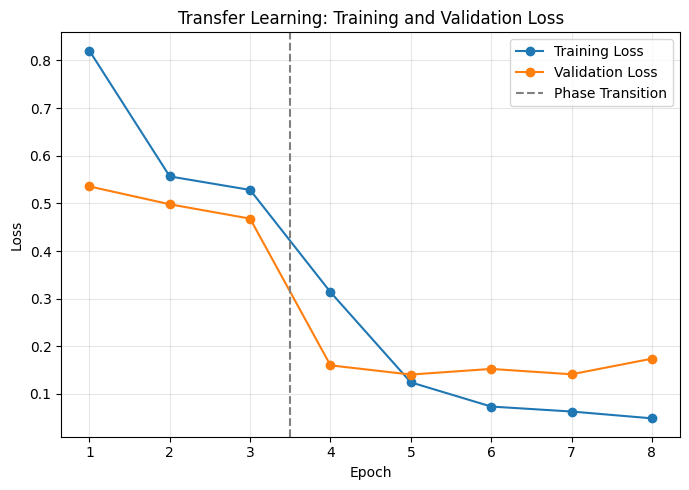

In [8]:
all_train_losses = phase1_train_losses + phase2_train_losses
all_val_losses = phase1_val_losses + phase2_val_losses
epochs = range(1, len(all_train_losses) + 1)
plt.figure(figsize=(7, 5))
plt.plot(epochs, all_train_losses, marker="o", label="Training Loss")
plt.plot(epochs, all_val_losses, marker="o", label="Validation Loss")
plt.axvline(
    x=PHASE1_EPOCHS + 0.5,
    linestyle="--",
    color="gray",
    label="Phase Transition"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning: Training and Validation Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Results

### Comparison of Fine-Tuning Phases

The performance of the transfer learning model is evaluated after each stage of
fine-tuning to measure the impact of progressively adapting the pretrained
network.

The first phase represents training with a frozen backbone, while the second
phase includes fine-tuning of the deeper convolutional layers. Comparing the
Macro F1-scores from both phases highlights the performance improvement gained
through selective fine-tuning.

In [9]:
print(f"{'Setting':<25}{'Macro F1':>10}")
print(f"{'Frozen (Phase 1)':<25}{phase1_macro_f1:>10.3f}")
print(f"{'Unfrozen (Phase 2)':<25}{phase2_macro_f1:>10.3f}")

Setting                    Macro F1
Frozen (Phase 1)              0.849
Unfrozen (Phase 2)            0.948


The results show that selectively fine-tuning the deeper layers of the
pretrained ResNet-18 substantially improves classification performance.
Unfreezing the last two residual blocks increased the Macro F1-score from
**0.849** to **0.948**, demonstrating the effectiveness of the two-phase
fine-tuning strategy.

### Per-class F1 and confusion matrix on EuroSAT validation

Per-class F1 (EuroSAT validation):
  AnnualCrop: 0.930
  Forest: 0.990
  HerbaceousVegetation: 0.955
  Highway: 0.901
  Industrial: 0.963
  Pasture: 0.950
  PermanentCrop: 0.895
  Residential: 0.984
  River: 0.922
  SeaLake: 0.993


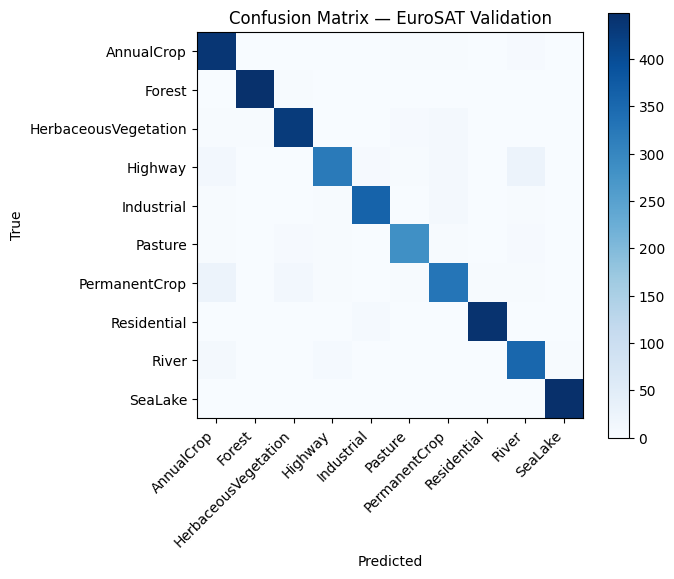

In [10]:
eurosat_per_class_f1 = f1_score(phase2_labels, phase2_preds, average=None)

print("Per-class F1 (EuroSAT validation):")
for name, score in zip(class_names, eurosat_per_class_f1):
    print(f"  {name}: {score:.3f}")

cm = confusion_matrix(phase2_labels, phase2_preds, labels=range(len(class_names)))

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — EuroSAT Validation")
plt.tight_layout()
plt.show()

### Download the UC Merced Dataset

To evaluate how well the trained model generalizes to unseen satellite imagery,
the UC Merced Land Use dataset is used as an external holdout dataset.

Instead of downloading the dataset from the original UC Merced server (which is
often unavailable or slow), the dataset is retrieved directly from Kaggle using
the `kagglehub` library. This approach provides a more reliable and
reproducible way to access the dataset within Google Colab.

In [12]:
!pip -q install kagglehub

In [13]:
import kagglehub

path = kagglehub.dataset_download(
    "abdulhasibuddin/uc-merced-land-use-dataset"
)

print("Dataset downloaded to:", path)

100%|██████████| 317M/317M [00:07<00:00, 44.0MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/abdulhasibuddin/uc-merced-land-use-dataset/versions/1


In [14]:
import os

for root, dirs, files in os.walk(path):
    print(root)

/root/.cache/kagglehub/datasets/abdulhasibuddin/uc-merced-land-use-dataset/versions/1
/root/.cache/kagglehub/datasets/abdulhasibuddin/uc-merced-land-use-dataset/versions/1/UCMerced_LandUse
/root/.cache/kagglehub/datasets/abdulhasibuddin/uc-merced-land-use-dataset/versions/1/UCMerced_LandUse/Images
/root/.cache/kagglehub/datasets/abdulhasibuddin/uc-merced-land-use-dataset/versions/1/UCMerced_LandUse/Images/overpass
/root/.cache/kagglehub/datasets/abdulhasibuddin/uc-merced-land-use-dataset/versions/1/UCMerced_LandUse/Images/sparseresidential
/root/.cache/kagglehub/datasets/abdulhasibuddin/uc-merced-land-use-dataset/versions/1/UCMerced_LandUse/Images/beach
/root/.cache/kagglehub/datasets/abdulhasibuddin/uc-merced-land-use-dataset/versions/1/UCMerced_LandUse/Images/mobilehomepark
/root/.cache/kagglehub/datasets/abdulhasibuddin/uc-merced-land-use-dataset/versions/1/UCMerced_LandUse/Images/runway
/root/.cache/kagglehub/datasets/abdulhasibuddin/uc-merced-land-use-dataset/versions/1/UCMerced_L

### Load the UC Merced Holdout Dataset

The UC Merced Land Use dataset is used as an external holdout dataset to assess
how well the fine-tuned model generalizes to satellite imagery beyond EuroSAT.

The dataset is downloaded automatically using `kagglehub` and loaded with the
same preprocessing pipeline used for EuroSAT to ensure a consistent evaluation.

In [15]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

UCM_IMAGES_DIR = os.path.join(
    path,
    "UCMerced_LandUse",
    "Images"
)

ucm_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    ),
])

ucm_dataset = datasets.ImageFolder(
    root=UCM_IMAGES_DIR,
    transform=ucm_transform
)

ucm_loader = DataLoader(
    ucm_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Number of classes :", len(ucm_dataset.classes))
print("Total images      :", len(ucm_dataset))
print("Classes:")
print(ucm_dataset.classes)

Number of classes : 21
Total images      : 2100
Classes:
['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


## Evaluation on the UC Merced Holdout Dataset

To assess the model's ability to generalize beyond the EuroSAT dataset, the
fine-tuned ResNet-18 is evaluated on the UC Merced Land Use dataset.

Since the two datasets use different class definitions, predictions are
compared using the original label spaces without applying semantic or manual
class mappings. This evaluation provides an indication of how well the learned
features transfer to a different remote sensing benchmark.

In [16]:
ucm_preds_idx, ucm_true_idx = get_predictions(model, ucm_loader)

ucm_true_names = [ucm_dataset.classes[i] for i in ucm_true_idx]
ucm_pred_names = [class_names[i].lower() for i in ucm_preds_idx]
correct = [
    true_name.lower() == pred_name
    for true_name, pred_name in zip(ucm_true_names, ucm_pred_names)
]
print(f"Exact-name Accuracy: {np.mean(correct):.3f}")
ucm_f1 = f1_score(
    ucm_true_names,
    ucm_pred_names,
    labels=ucm_dataset.classes,
    average=None,
    zero_division=0
)
ucm_macro_f1 = f1_score(
    ucm_true_names,
    ucm_pred_names,
    labels=ucm_dataset.classes,
    average="macro",
    zero_division=0
)
print("\nPer-class F1 Score")
for name, score in zip(ucm_dataset.classes, ucm_f1):
    print(f"{name:<20} {score:.3f}")
print(f"\nMacro F1 Score: {ucm_macro_f1:.3f}")

Exact-name Accuracy: 0.041

Per-class F1 Score
agricultural         0.000
airplane             0.000
baseballdiamond      0.000
beach                0.000
buildings            0.000
chaparral            0.000
denseresidential     0.000
forest               0.411
freeway              0.000
golfcourse           0.000
harbor               0.000
intersection         0.000
mediumresidential    0.000
mobilehomepark       0.000
overpass             0.000
parkinglot           0.000
river                0.361
runway               0.000
sparseresidential    0.000
storagetanks         0.000
tenniscourt          0.000

Macro F1 Score: 0.037


### Confusion Matrix

The confusion matrix summarizes the model's predictions on the UC Merced
holdout dataset.

Rows represent the true UC Merced classes, while columns represent the
predicted EuroSAT classes. The matrix helps visualize how the learned
representations transfer across datasets and highlights common
misclassification patterns.

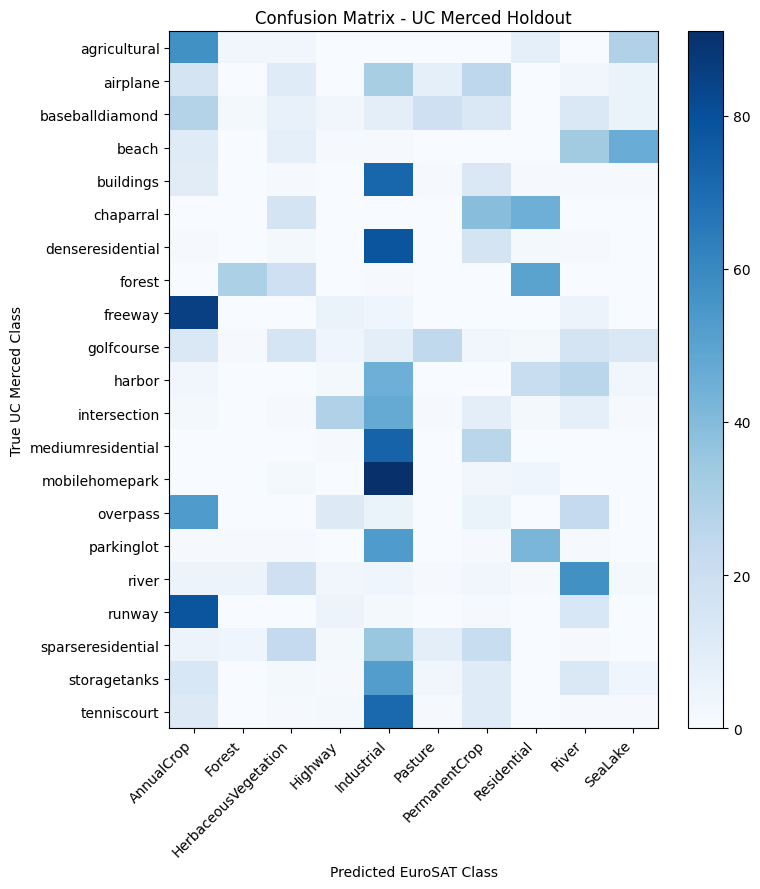

In [17]:
ucm_cm = np.zeros((len(ucm_dataset.classes),len(class_names)),dtype=int)
for true_idx, pred_idx in zip(ucm_true_idx, ucm_preds_idx):
    ucm_cm[true_idx, pred_idx] += 1
plt.figure(figsize=(8, 9))
plt.imshow(ucm_cm, cmap="Blues", aspect="auto")
plt.colorbar()
plt.xticks(range(len(class_names)),class_names,rotation=45,ha="right")
plt.yticks(range(len(ucm_dataset.classes)),ucm_dataset.classes)
plt.xlabel("Predicted EuroSAT Class")
plt.ylabel("True UC Merced Class")
plt.title("Confusion Matrix - UC Merced Holdout")
plt.tight_layout()
plt.show()

### Save the fine-tuned model

Note: in Colab, files are lost when the runtime disconnects — download this
file or copy it to Google Drive if you want to keep it.

In [19]:
torch.save(model.state_dict(), "model.pt")
print("Model saved to model.pt")

Model saved to model.pt


In [20]:
from google.colab import files

files.download("model.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

- Fine-tuned a pretrained ResNet-18 using a two-phase training strategy,
  beginning with classifier head training followed by selective fine-tuning of
  the deeper convolutional layers.
- Compared the performance of both fine-tuning phases, demonstrating the
  improvement achieved by unfreezing the final residual blocks.
- Evaluated the model using per-class F1-score, Macro F1-score, and a confusion
  matrix on the EuroSAT validation set.
- Assessed the model's generalization on the UC Merced Land Use dataset as an
  external holdout benchmark.
- Saved the trained model weights for reuse in the temporal change detection
  stage and future inference.